TRANSFORMER (BASE) - English to Arabic Translation

✓ Using device: cuda
✓ GPU: Tesla T4
✓ Memory: 15.8 GB

UPLOAD YOUR DATASET FILES

📁 Step 1: Upload your ENGLISH file (.en):


Saving Tatoeba.ar-enDATASET2.en to Tatoeba.ar-enDATASET2.en
✓ English file uploaded: Tatoeba.ar-enDATASET2.en

📁 Step 2: Upload your ARABIC file (.ar):


Saving Tatoeba.ar-enDATASET.ar to Tatoeba.ar-enDATASET.ar
✓ Arabic file uploaded: Tatoeba.ar-enDATASET.ar

LOADING AND PREPARING DATA
✓ Loaded 20000 sentence pairs

📝 Sample sentence pairs:
  EN: Nancy looks so tired.
  AR: بدا التعب على نانسي.

  EN: She is keen on birds and flowers.
  AR: هي تحب الطيور و الأزهار.

  EN: Is there an elevator?
  AR: هل هناك مصعد؟

✓ Train: 16000 | Val: 2000 | Test: 2000

Building vocabularies...
English:
  Vocabulary size: 7521
  Word coverage: 100.0%
Arabic:
  Vocabulary size: 18983
  Word coverage: 100.0%

✓ DataLoaders created

INITIALIZING MODEL
✓ Model initialized
  Parameters: 19,036,455
  Source vocab: 7521
  Target vocab: 18983
  d_model: 256
  Heads: 8
  Layers: 4

TRAINING


Epoch  1/20 | Train Loss: 7.0597 | Val Loss: 6.3420
           └── ✓ Best model so far!


Epoch  2/20 | Train Loss: 6.1065 | Val Loss: 6.0867
           └── ✓ Best model so far!


...

Epoch 18/20 | Train Loss: 3.6046 | Val Loss: 5.4161


Epoch 19/20 | Train Loss: 3.4800 | Val Loss: 5.4376


Epoch 20/20 | Train Loss: 3.3615 | Val Loss: 5.4619

✓ Training complete!

EVALUATION
Test Loss: 5.4330

Calculating BLEU score on test set...


Translating: 100%|██████████| 200/200 [00:09<00:00, 20.78it/s]



📊 BLEU SCORE: 4.95

BLEU Score Interpretation:
  < 10  : Almost useless
  10-19 : Hard to understand
  20-29 : Clear gist
  30-39 : Understandable
  40-49 : High quality
  50+   : Very high quality

SAMPLE TRANSLATIONS

🇬🇧 English: Hello, how are you?
🇸🇦 Arabic:  كيف حالك ؟

🇬🇧 English: What is your name?
🇸🇦 Arabic:  ماذا حالك ؟

🇬🇧 English: Thank you very much.
🇸🇦 Arabic:  شكراً لك من أجلك .

🇬🇧 English: I love learning languages.
🇸🇦 Arabic:  أحب اللغات .

🇬🇧 English: Good morning!
🇸🇦 Arabic:  صباح الخير .

🇬🇧 English: I miss you.
🇸🇦 Arabic:  أنا مشتاق لك .

🇬🇧 English: I have to go to sleep.
🇸🇦 Arabic:  علي أن أذهب إلى النوم .

🇬🇧 English: I love you.
🇸🇦 Arabic:  أنا أحبك .

TEST SET EXAMPLES (with reference)

[1] English:   Ziri caught a bus.
    Reference: ذهب زيري في حافلة.
    Model:     جلس زيري إلى الأدغال .

[2] English:   Motherhood and childhood are entitled to special care and assistance. All children, whether born in or out of wedlock, shall enjoy the same social protecti

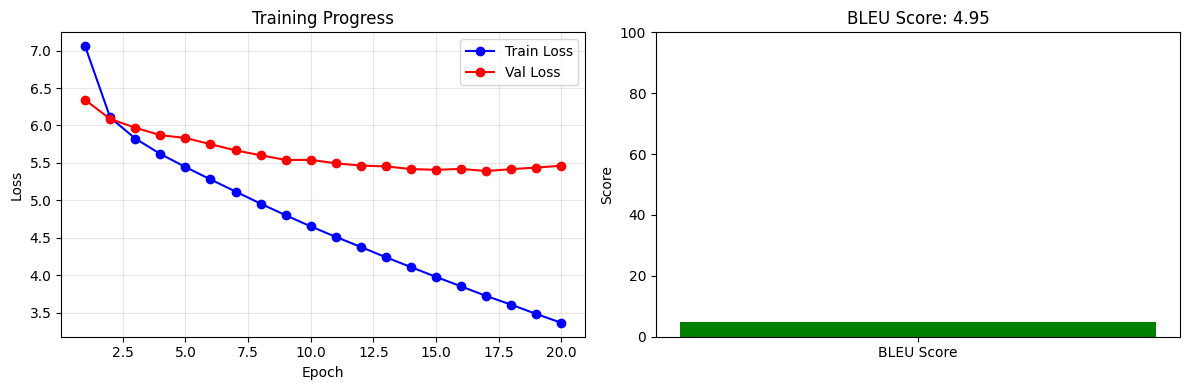


FINAL SUMMARY
✓ Model: Transformer (Base)
✓ Parameters: 19,036,455
✓ Source Vocabulary: 7521
✓ Target Vocabulary: 18983
✓ Final Train Loss: 3.3615
✓ Final Val Loss: 5.4619
✓ Test Loss: 5.4330
✓ BLEU Score: 4.95


In [2]:

# ============================================================================
# SECTION 1: SETUP AND IMPORTS
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import math
import numpy as np
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("=" * 60)
print("TRANSFORMER (BASE) - English to Arabic Translation")
print("=" * 60)
print(f"\n✓ Using device: {device}")

if device.type == 'cuda':
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠ WARNING: No GPU detected! Training will be slow.")
    print("  Go to Runtime -> Change runtime type -> GPU")

# ============================================================================
# SECTION 2: UPLOAD DATASET (TWO FILES)
# ============================================================================

from google.colab import files

print("\n" + "=" * 60)
print("UPLOAD YOUR DATASET FILES")
print("=" * 60)

# Upload English file
print("\n📁 Step 1: Upload your ENGLISH file (.en):")
uploaded_en = files.upload()
en_filename = list(uploaded_en.keys())[0]
print(f"✓ English file uploaded: {en_filename}")

# Upload Arabic file
print("\n📁 Step 2: Upload your ARABIC file (.ar):")
uploaded_ar = files.upload()
ar_filename = list(uploaded_ar.keys())[0]
print(f"✓ Arabic file uploaded: {ar_filename}")

# ============================================================================
# SECTION 3: DATA PREPROCESSING CLASSES (IMPROVED)
# ============================================================================

class Vocabulary:
    """Build vocabulary from text data with special tokens."""

    def __init__(self, freq_threshold=1):  # Changed to 1 to include all words
        self.freq_threshold = freq_threshold
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}

    def build_vocabulary(self, sentence_list):
        """Build vocabulary from list of sentences."""
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

        for word, count in frequencies.items():
            if count >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1

        # Calculate coverage
        total_words = sum(frequencies.values())
        covered_words = sum(count for word, count in frequencies.items() if count >= self.freq_threshold)
        coverage = (covered_words / total_words * 100) if total_words > 0 else 0

        print(f"  Vocabulary size: {len(self.itos)}")
        print(f"  Word coverage: {coverage:.1f}%")

    def tokenize(self, text):
        """Improved tokenization for both English and Arabic."""
        # Normalize text
        text = text.strip().lower()
        # Add spaces around punctuation
        text = re.sub(r'([.,!?؟،])', r' \1 ', text)
        # Split and filter empty strings
        tokens = [t for t in text.split() if t]
        return tokens

    def numericalize(self, text):
        """Convert text to numerical indices."""
        tokens = self.tokenize(text)
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokens]

    def __len__(self):
        return len(self.itos)


class TranslationDataset(Dataset):
    """Dataset class for parallel corpus."""

    def __init__(self, src_sentences, tgt_sentences, src_vocab, tgt_vocab, max_len=100):
        self.src_sentences = src_sentences
        self.tgt_sentences = tgt_sentences
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src = self.src_sentences[idx]
        tgt = self.tgt_sentences[idx]

        src_indices = [self.src_vocab.stoi["<SOS>"]] + \
                     self.src_vocab.numericalize(src)[:self.max_len-2] + \
                     [self.src_vocab.stoi["<EOS>"]]

        tgt_indices = [self.tgt_vocab.stoi["<SOS>"]] + \
                     self.tgt_vocab.numericalize(tgt)[:self.max_len-2] + \
                     [self.tgt_vocab.stoi["<EOS>"]]

        return torch.tensor(src_indices), torch.tensor(tgt_indices)


def collate_fn(batch):
    """Custom collate function for padding sequences."""
    src_batch, tgt_batch = [], []

    for src, tgt in batch:
        src_batch.append(src)
        tgt_batch.append(tgt)

    src_batch = pad_sequence(src_batch, padding_value=0, batch_first=True)
    tgt_batch = pad_sequence(tgt_batch, padding_value=0, batch_first=True)

    return src_batch, tgt_batch


def load_parallel_files(en_file, ar_file, max_samples=None):
    """Load parallel corpus from two separate files."""
    english_sentences = []
    arabic_sentences = []

    # Read English file
    with open(en_file, 'r', encoding='utf-8') as f:
        for line in f:
            english_sentences.append(line.strip())

    # Read Arabic file
    with open(ar_file, 'r', encoding='utf-8') as f:
        for line in f:
            arabic_sentences.append(line.strip())

    # Ensure same length
    min_len = min(len(english_sentences), len(arabic_sentences))
    english_sentences = english_sentences[:min_len]
    arabic_sentences = arabic_sentences[:min_len]

    # Filter out empty lines and very long sentences
    filtered_en, filtered_ar = [], []
    for en, ar in zip(english_sentences, arabic_sentences):
        if en.strip() and ar.strip():
            # Filter sentences that are too long or too short
            en_words = len(en.split())
            ar_words = len(ar.split())
            if 2 <= en_words <= 50 and 2 <= ar_words <= 50:
                filtered_en.append(en)
                filtered_ar.append(ar)

    # Shuffle data for better training
    combined = list(zip(filtered_en, filtered_ar))
    np.random.shuffle(combined)
    filtered_en, filtered_ar = zip(*combined) if combined else ([], [])
    filtered_en, filtered_ar = list(filtered_en), list(filtered_ar)

    # Apply max_samples limit
    if max_samples:
        filtered_en = filtered_en[:max_samples]
        filtered_ar = filtered_ar[:max_samples]

    return filtered_en, filtered_ar

# ============================================================================
# SECTION 4: TRANSFORMER ARCHITECTURE
# ============================================================================

class PositionalEncoding(nn.Module):
    """
    Positional Encoding using sine and cosine functions.
    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention mechanism.
    Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) * V
    """

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        return torch.matmul(attention_weights, V), attention_weights

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        attn_output, _ = self.scaled_dot_product_attention(Q, K, V, mask)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        return self.W_o(attn_output)


class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network."""

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))


class EncoderLayer(nn.Module):
    """Single Transformer Encoder Layer."""

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output = self.self_attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x


class DecoderLayer(nn.Module):
    """Single Transformer Decoder Layer."""

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        attn_output = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attention(x, encoder_output, encoder_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x


class TransformerEncoder(nn.Module):
    """Transformer Encoder."""

    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.d_model = d_model

    def forward(self, x, mask=None):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x


class TransformerDecoder(nn.Module):
    """Transformer Decoder."""

    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.d_model = d_model

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return x


class Transformer(nn.Module):
    """
    Complete Transformer Model for Sequence-to-Sequence Translation.
    Based on "Attention Is All You Need" (Vaswani et al., 2017)
    """

    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, num_heads=8,
                 d_ff=1024, num_encoder_layers=4, num_decoder_layers=4, dropout=0.1):
        super().__init__()

        self.encoder = TransformerEncoder(
            src_vocab_size, d_model, num_heads, d_ff, num_encoder_layers, dropout
        )
        self.decoder = TransformerDecoder(
            tgt_vocab_size, d_model, num_heads, d_ff, num_decoder_layers, dropout
        )
        self.output_projection = nn.Linear(d_model, tgt_vocab_size)

        self._init_parameters()

    def _init_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        tgt_pad_mask = (tgt != 0).unsqueeze(1).unsqueeze(2)
        tgt_len = tgt.size(1)
        tgt_causal_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=tgt.device)).bool()
        tgt_mask = tgt_pad_mask & tgt_causal_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        encoder_output = self.encoder(src, src_mask)
        decoder_output = self.decoder(tgt, encoder_output, src_mask, tgt_mask)
        output = self.output_projection(decoder_output)
        return output

# ============================================================================
# SECTION 5: BLEU SCORE CALCULATION (WITH SMOOTHING)
# ============================================================================

def calculate_bleu(references, candidates, max_n=4):
    """
    Calculate BLEU score with smoothing to avoid 0 scores.

    Uses smoothing method to handle cases where higher-order n-grams
    have zero counts (common with short sentences).
    """

    def get_ngrams(tokens, n):
        """Extract n-grams from token list."""
        if len(tokens) < n:
            return []
        return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

    def clip_count(candidate_ngrams, reference_ngrams):
        """Calculate clipped n-gram counts."""
        ref_counts = Counter(reference_ngrams)
        cand_counts = Counter(candidate_ngrams)

        clipped = sum(min(count, ref_counts[ngram])
                     for ngram, count in cand_counts.items())
        return clipped

    precisions = []

    for n in range(1, max_n + 1):
        total_clipped = 0
        total_count = 0

        for ref, cand in zip(references, candidates):
            # Filter out <UNK> tokens for fair comparison
            ref_filtered = [t for t in ref if t != '<unk>' and t != '<UNK>']
            cand_filtered = [t for t in cand if t != '<unk>' and t != '<UNK>']

            ref_ngrams = get_ngrams(ref_filtered, n)
            cand_ngrams = get_ngrams(cand_filtered, n)

            total_clipped += clip_count(cand_ngrams, ref_ngrams)
            total_count += len(cand_ngrams)

        # Smoothing: add small value to avoid zero
        if total_count == 0:
            precision = 0
        else:
            precision = (total_clipped + 0.1) / (total_count + 0.1)  # Add-k smoothing
        precisions.append(precision)

    # Geometric mean of precisions
    if min(precisions) > 0:
        log_precision_sum = sum(math.log(p) for p in precisions) / max_n
        geo_mean = math.exp(log_precision_sum)
    else:
        # Fallback: use only unigram precision
        geo_mean = precisions[0] if precisions[0] > 0 else 0

    # Brevity penalty
    ref_len = sum(len([t for t in r if t != '<unk>' and t != '<UNK>']) for r in references)
    cand_len = sum(len([t for t in c if t != '<unk>' and t != '<UNK>']) for c in candidates)

    if cand_len == 0:
        return 0.0

    if cand_len < ref_len:
        bp = math.exp(1 - ref_len / cand_len)
    else:
        bp = 1.0

    bleu = bp * geo_mean
    return bleu * 100  # Return as percentage

# ============================================================================
# SECTION 6: TRAINING FUNCTIONS
# ============================================================================

def train_epoch(model, dataloader, optimizer, criterion, clip_grad=1.0):
    """Train for one epoch."""
    model.train()
    total_loss = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for src, tgt in progress_bar:
        src, tgt = src.to(device), tgt.to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        optimizer.zero_grad()
        output = model(src, tgt_input)

        output = output.reshape(-1, output.size(-1))
        tgt_output = tgt_output.reshape(-1)

        loss = criterion(output, tgt_output)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(dataloader)


def evaluate(model, dataloader, criterion):
    """Evaluate the model."""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)

            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            output = model(src, tgt_input)
            output = output.reshape(-1, output.size(-1))
            tgt_output = tgt_output.reshape(-1)

            loss = criterion(output, tgt_output)
            total_loss += loss.item()

    return total_loss / len(dataloader)


def translate_sentence(model, sentence, src_vocab, tgt_vocab, max_len=50):
    """Translate a single sentence using greedy decoding."""
    model.eval()

    src_indices = [src_vocab.stoi["<SOS>"]] + \
                  src_vocab.numericalize(sentence) + \
                  [src_vocab.stoi["<EOS>"]]
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)

    src_mask = (src_tensor != 0).unsqueeze(1).unsqueeze(2)

    with torch.no_grad():
        encoder_output = model.encoder(src_tensor, src_mask)
        tgt_indices = [tgt_vocab.stoi["<SOS>"]]

        for _ in range(max_len):
            tgt_tensor = torch.tensor(tgt_indices).unsqueeze(0).to(device)
            tgt_len = tgt_tensor.size(1)
            tgt_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=device)).bool()
            tgt_mask = tgt_mask.unsqueeze(0).unsqueeze(0)

            decoder_output = model.decoder(tgt_tensor, encoder_output, src_mask, tgt_mask)
            output = model.output_projection(decoder_output)

            next_token = output[0, -1, :].argmax().item()
            tgt_indices.append(next_token)

            if next_token == tgt_vocab.stoi["<EOS>"]:
                break

    translated_tokens = [tgt_vocab.itos[idx] for idx in tgt_indices[1:-1]
                        if idx in tgt_vocab.itos]
    return ' '.join(translated_tokens)

# ============================================================================
# SECTION 7: MAIN EXECUTION
# ============================================================================

# Hyperparameters - ADJUSTED FOR BETTER RESULTS
MAX_SAMPLES = 20000      # Use more data
BATCH_SIZE = 64          # Larger batch
D_MODEL = 256            # Model dimension
NUM_HEADS = 8            # Attention heads
D_FF = 1024              # Feed-forward dimension
NUM_LAYERS = 4           # Encoder/Decoder layers
DROPOUT = 0.1
LEARNING_RATE = 0.0003   # Slightly higher learning rate
NUM_EPOCHS = 20          # More epochs

print("\n" + "=" * 60)
print("LOADING AND PREPARING DATA")
print("=" * 60)

# Load data from two separate files
english_sentences, arabic_sentences = load_parallel_files(en_filename, ar_filename, max_samples=MAX_SAMPLES)
print(f"✓ Loaded {len(english_sentences)} sentence pairs")

# Preview some examples
print("\n📝 Sample sentence pairs:")
for i in range(3):
    print(f"  EN: {english_sentences[i]}")
    print(f"  AR: {arabic_sentences[i]}")
    print()

# Split data
train_size = int(0.8 * len(english_sentences))
val_size = int(0.1 * len(english_sentences))

train_en = english_sentences[:train_size]
train_ar = arabic_sentences[:train_size]
val_en = english_sentences[train_size:train_size+val_size]
val_ar = arabic_sentences[train_size:train_size+val_size]
test_en = english_sentences[train_size+val_size:]
test_ar = arabic_sentences[train_size+val_size:]

print(f"✓ Train: {len(train_en)} | Val: {len(val_en)} | Test: {len(test_en)}")

# Build vocabularies with freq_threshold=1 to include all words
print("\nBuilding vocabularies...")
print("English:")
src_vocab = Vocabulary(freq_threshold=1)  # Include ALL words
src_vocab.build_vocabulary(train_en)

print("Arabic:")
tgt_vocab = Vocabulary(freq_threshold=1)  # Include ALL words
tgt_vocab.build_vocabulary(train_ar)

# Create datasets and dataloaders
train_dataset = TranslationDataset(train_en, train_ar, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_en, val_ar, src_vocab, tgt_vocab)
test_dataset = TranslationDataset(test_en, test_ar, src_vocab, tgt_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✓ DataLoaders created")

# Initialize model
print("\n" + "=" * 60)
print("INITIALIZING MODEL")
print("=" * 60)

model = Transformer(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_encoder_layers=NUM_LAYERS,
    num_decoder_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model initialized")
print(f"  Parameters: {num_params:,}")
print(f"  Source vocab: {len(src_vocab)}")
print(f"  Target vocab: {len(tgt_vocab)}")
print(f"  d_model: {D_MODEL}")
print(f"  Heads: {NUM_HEADS}")
print(f"  Layers: {NUM_LAYERS}")

# Setup training
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)  # Added label smoothing
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Training loop
print("\n" + "=" * 60)
print("TRAINING")
print("=" * 60)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"           └── ✓ Best model so far!")

    scheduler.step(val_loss)

print("\n✓ Training complete!")

# Load best model
if best_model_state:
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

# ============================================================================
# SECTION 8: EVALUATION WITH BLEU SCORE
# ============================================================================

print("\n" + "=" * 60)
print("EVALUATION")
print("=" * 60)

# Test loss
test_loss = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}")

# Calculate BLEU score
print("\nCalculating BLEU score on test set...")

references = []
candidates = []
num_samples = min(200, len(test_en))

for i in tqdm(range(num_samples), desc="Translating"):
    translation = translate_sentence(model, test_en[i], src_vocab, tgt_vocab)
    references.append(tgt_vocab.tokenize(test_ar[i]))
    candidates.append(translation.split())

bleu_score = calculate_bleu(references, candidates)

print("\n" + "=" * 60)
print(f"📊 BLEU SCORE: {bleu_score:.2f}")
print("=" * 60)

# BLEU score interpretation
print("\nBLEU Score Interpretation:")
print("  < 10  : Almost useless")
print("  10-19 : Hard to understand")
print("  20-29 : Clear gist")
print("  30-39 : Understandable")
print("  40-49 : High quality")
print("  50+   : Very high quality")

# ============================================================================
# SECTION 9: SAMPLE TRANSLATIONS
# ============================================================================

print("\n" + "=" * 60)
print("SAMPLE TRANSLATIONS")
print("=" * 60)

test_sentences = [
    "Hello, how are you?",
    "What is your name?",
    "Thank you very much.",
    "I love learning languages.",
    "Good morning!",
    "I miss you.",
    "I have to go to sleep.",
    "I love you."
]

for sent in test_sentences:
    translation = translate_sentence(model, sent, src_vocab, tgt_vocab)
    print(f"\n🇬🇧 English: {sent}")
    print(f"🇸🇦 Arabic:  {translation}")

# Test set examples with reference
print("\n" + "=" * 60)
print("TEST SET EXAMPLES (with reference)")
print("=" * 60)

for i in range(min(10, len(test_en))):
    translation = translate_sentence(model, test_en[i], src_vocab, tgt_vocab)
    print(f"\n[{i+1}] English:   {test_en[i]}")
    print(f"    Reference: {test_ar[i]}")
    print(f"    Model:     {translation}")

# ============================================================================
# SECTION 10: VISUALIZATION
# ============================================================================

print("\n" + "=" * 60)
print("TRAINING VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, NUM_EPOCHS+1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(['BLEU Score'], [bleu_score], color='green')
plt.ylabel('Score')
plt.title(f'BLEU Score: {bleu_score:.2f}')
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('transformer_results.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 11: FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"✓ Model: Transformer (Base)")
print(f"✓ Parameters: {num_params:,}")
print(f"✓ Source Vocabulary: {len(src_vocab)}")
print(f"✓ Target Vocabulary: {len(tgt_vocab)}")
print(f"✓ Final Train Loss: {train_losses[-1]:.4f}")
print(f"✓ Final Val Loss: {val_losses[-1]:.4f}")
print(f"✓ Test Loss: {test_loss:.4f}")
print(f"✓ BLEU Score: {bleu_score:.2f}")

